# Exercises for Part-1

This notebook shows and writes some exercises based on the [`Sionna tutorial`](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Hello_World.html) and my own [`notes`](../beginners.ipynb).

The exercises are generated by Claude AI and solved by me.

## 1. Shapes

Generate bits with BinarySource for BITS_PER_SYMBOL = 6 and BATCH_SIZE = 500. Print the shape and confirm it matches what you expect. Then map them to a QAM constellation and print the shape of x. Explain in a comment why the second dimension shrank by a factor of 6.

In [ ]:
# Importing necessary modules
from sionna.phy.mapping import BinarySource, Constellation, Mapper

# Declaring bit and batch size
BITS_PER_SYMBOL = 6
BATCH_SIZE = 500

# Opening a source and taking generating bits
source = BinarySource()
bits = source([BATCH_SIZE, BITS_PER_SYMBOL])

# Checking its shape
print(bits.shape)
print(bits.dtype)
print(bits[:1])

# Declaring the constellation
constellation = Constellation("qam", BITS_PER_SYMBOL)

# Wiring through the mapper
mapper = Mapper(constellation=constellation)
x = mapper(bits)

# Checking the final shape
print(x.shape)
print(x.dtype)
print(x[:1])

"""
We can see the before mapping bits according to the constellation,
each bits where of float32 and of were represented by 6 bits.

The final shape became type complex64 represented by only one complex number.

The reason why the shape changed is 
[0., 1., 1., 0., 1., 1.] were simply mapped to [1.0801-0.1543j].

the second dimension shrinks by a factor of 6 because 
Mapper groups every num_bits_per_symbol (=6) consecutive bits
into one constellation symbol, so 500*6 bitsbecome 500*1 symbols

each symbol now carries 6 bits' worth of information encoded in its position
on the constellation, not 6 separate values.

"""


torch.Size([500, 6])
torch.float32
tensor([[0., 1., 1., 1., 0., 1.]], device='cuda:0')
torch.Size([500, 1])
torch.complex64
tensor([[0.7715-1.0801j]], device='cuda:0')


'\nWe can see the before mapping bits according to the constellation,\neach bits where of float32 and of were represented by 6 bits.\n\nThe final shape became type complex64 represented by only one complex number.\n\nThe reason why the shape changed is \n[0., 1., 1., 0., 1., 1.] were simply mapped to [1.0801-0.1543j].\n'

## 2. Constellation comparison

Create two constellations — QAM with num_bits_per_symbol = 2 and QAM with num_bits_per_symbol = 6 — and plot both with .show(). In a comment, describe how the number of points and their spacing changes, and why.

'\n\nLet us name the constellation 1 which has 2 num of bits per symbol constOne\nand the other one as constTwo.\n\nconstOne has only 4 points in the which forms into a square with labels:\n[10, 00, 11, 01].\n\nconstTwo has 8x8 and is also forming a square (but I am not sure if we can\nactually print these out properly?)\n\nThe numbers\n\n'

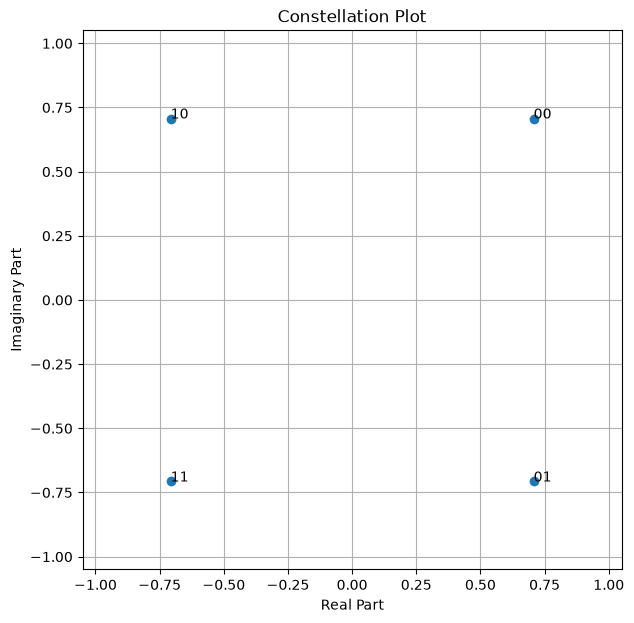

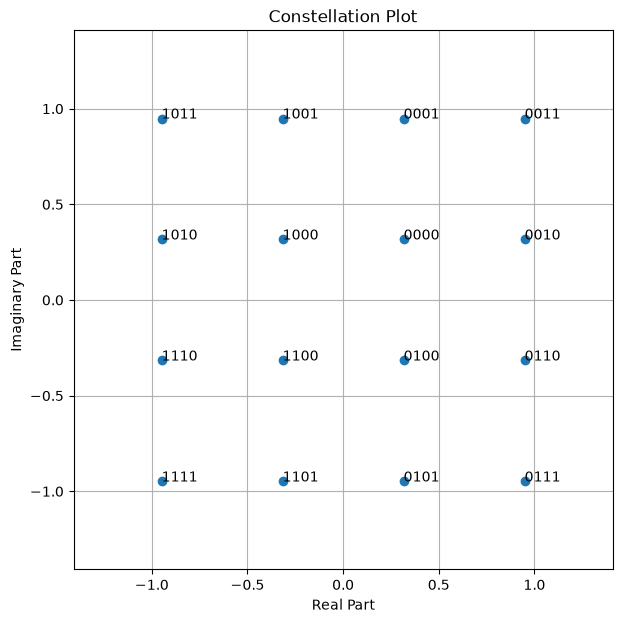

In [ ]:
from sionna.phy.mapping import Constellation

NUM_OF_BITS_PER_SYMBOL_1 = 2
NUM_OF_BITS_PER_SYMBOL_2 = 6

constellation_1 = Constellation("qam", NUM_OF_BITS_PER_SYMBOL_1)
constellation_2 = Constellation("qam", NUM_OF_BITS_PER_SYMBOL_2)

constellation_1.show()
constellation_2.show()


"""

Let us name the constellation 1 which has 2 num of bits per symbol constOne
and the other one as constTwo.

constOne has only 4 points in the which forms into a square with labels:
[10, 00, 11, 01].

constTwo has 8x8 and is also forming a square (but I am not sure if we can
actually print these out properly?)

The labeling must be according to a rule I cannot figure out yet. 

"""

NUM_OF_BITS_PER_SYMBOL_3 = 4

constellation_3 = Constellation("qam", NUM_OF_BITS_PER_SYMBOL_3)

constellation_3.show()

"""

The constThree further confirms this. The numbers on the labels of the points
are not incremental.

This is called Gray coding. Sionna labels adjacent constellation points so
they differ by exactly one bit, which minimizes bit errors when noise pushes
a symbol into a neighboring point.

It's deliberately not sequential binary counting.

"""

## 3. PAM instead of QAM

Repeat the "Finally Combining Everything" pipeline but swap "qam" for "pam". Note: PAM constellations are real-valued. What do you expect the scatter plot to look like differently compared to QAM, and does the code run without modification? If not, what did you have to change?

Text(0.5, 1.0, 'PAM received symbols')

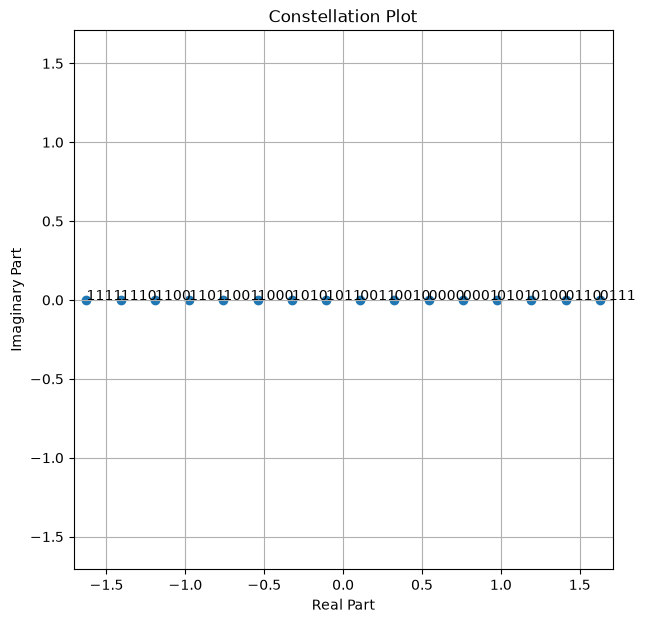

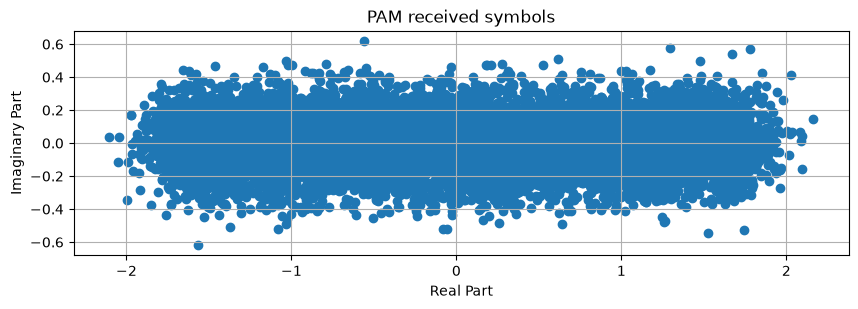

In [56]:
from sionna.phy.mapping import Mapper, Constellation, BinarySource
from sionna.phy.utils import ebnodb2no
from sionna.phy.channel import AWGN

import matplotlib.pyplot as plt
import numpy as np

BITS_PER_SYMBOL = 4
BATCH_SIZE = 10000

source = BinarySource()
bits = source([BATCH_SIZE, BITS_PER_SYMBOL])

constellation = Constellation("pam", BITS_PER_SYMBOL)

constellation.show()

# constellation = Constellation("qam", BITS_PER_SYMBOL)

# constellation.show()

"""

The constellations' scatterplot change by its modulation type.
Namely, qam shows a square like plot where the more bits_per_symbol there is
denser the plots. 

'pam' on the otherhand shows a line progression near the 0.0
Same logic applies here.

"""

mapper = Mapper(constellation=constellation)

x = mapper(bits)

awgn = AWGN()

CODE_RATE = 0.5
EBNO_DB = 10

no = ebnodb2no( EBNO_DB, BITS_PER_SYMBOL, CODE_RATE )

y = awgn( x, no ).cpu()

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
plt.scatter(np.real(y), np.imag(y))
ax.set_aspect("equal", adjustable="box")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True)
plt.title("PAM received symbols")

## 4. Sweeping Eb/N0

Write a loop that computes y for EBNO_DB values of [0, 5, 10, 15, 20] (keep everything else fixed), and produce one scatter plot per value (either 5 subplots or 5 separate figures). Describe qualitatively how the cloud of received points changes as Eb/N0 increases.

torch.complex64
torch.complex64
torch.complex64
torch.complex64
torch.complex64
torch.complex64


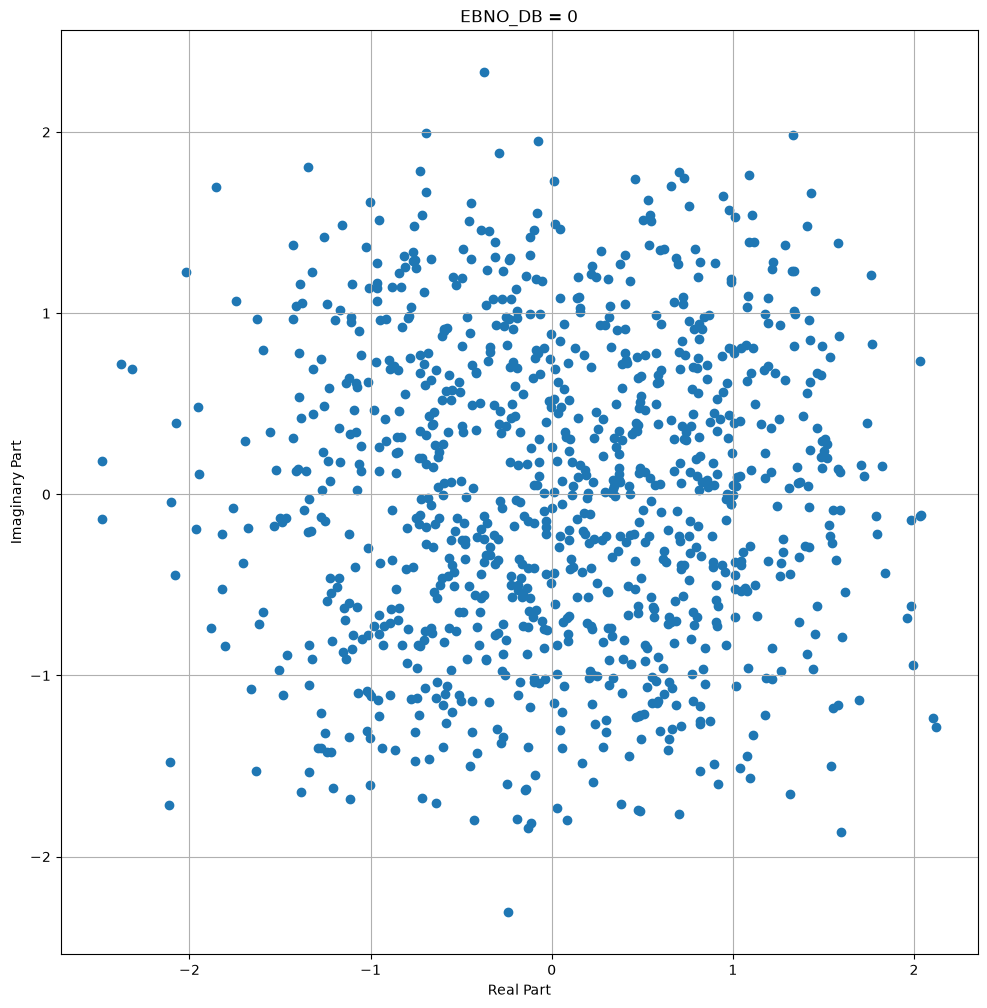

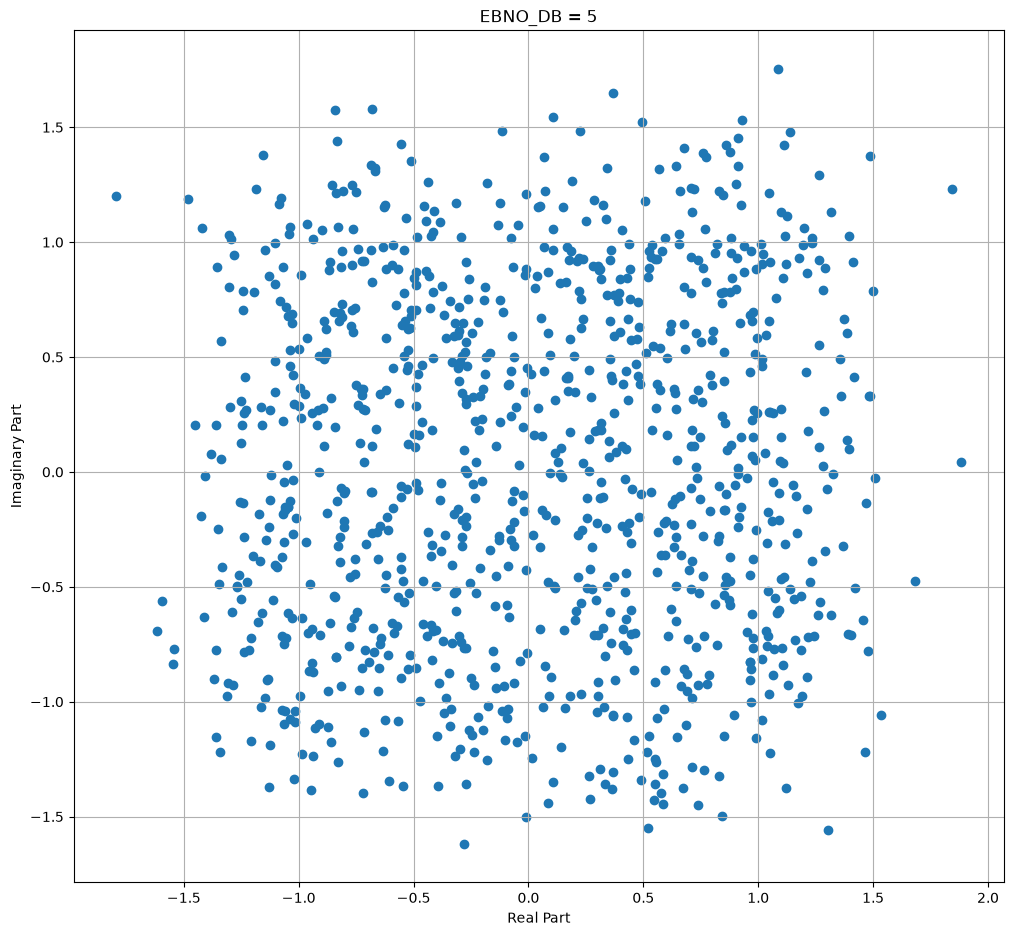

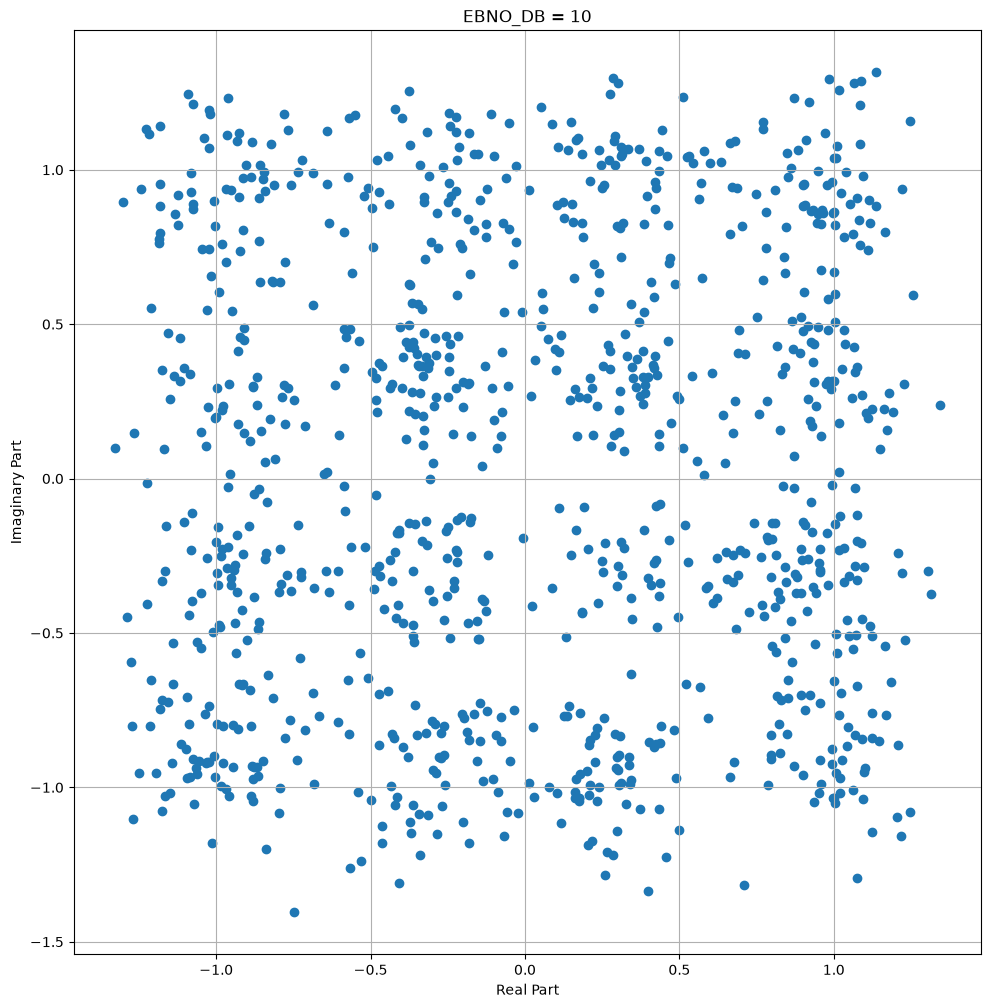

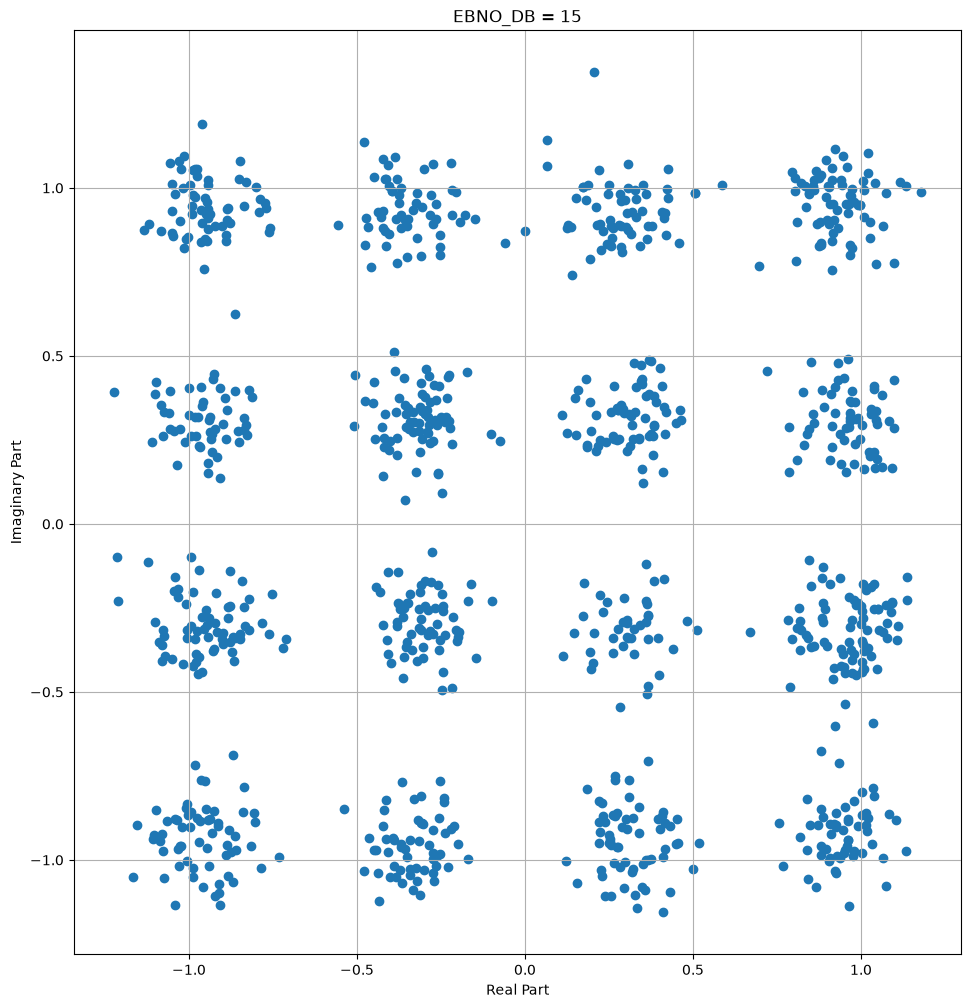

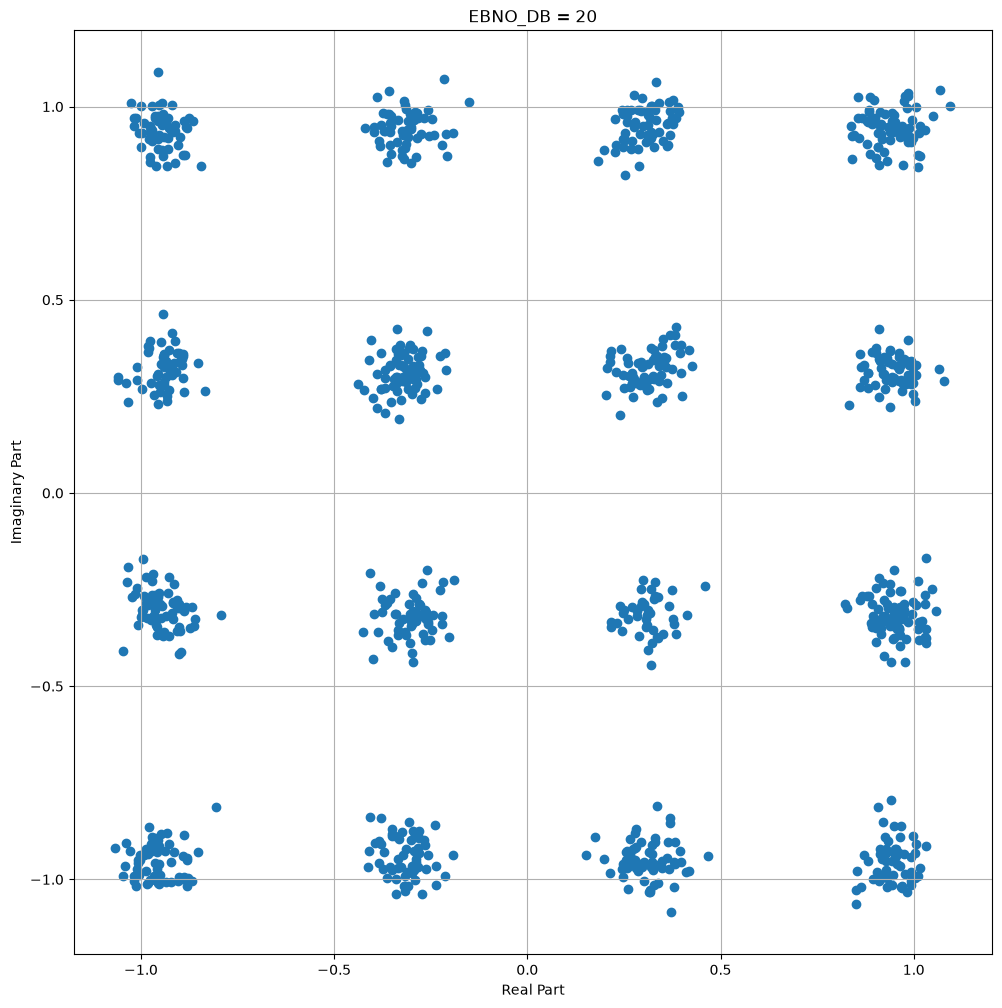

In [ ]:
# Importing necessary modules and classes
from sionna.phy.mapping import Mapper, Constellation, BinarySource
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no

import matplotlib.pyplot as plt
import numpy as np

# Declaring the variables
BITS_PER_SYMBOL = 4
BATCH_SIZE = 1000

# Creeating the source and generating bits from it
source = BinarySource()
bits = source([BATCH_SIZE, BITS_PER_SYMBOL])

# Declaring the Constellation
constellation = Constellation("qam", BITS_PER_SYMBOL)

# Wiring through the mapper
mapper = Mapper(constellation=constellation)

x = mapper(bits)
print(x.dtype)

# Generating No/dB
EBNO_DB_VALUES = [0, 5, 10, 15, 20]
CODE_RATE = 0.5

# Declaring white gaussian noise
awgn = AWGN()

for EBNO_DB in EBNO_DB_VALUES:
    no = ebnodb2no(EBNO_DB, BITS_PER_SYMBOL, CODE_RATE)

    y = awgn(x, no).cpu()
    # print(y.dtype)

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111)
    plt.scatter(np.real(y), np.imag(y));
    ax.set_aspect("equal", adjustable="box")
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True, which="both", axis="both")
    plt.title("EBNO_DB = " + str(EBNO_DB));

> We can see that as EDNO_DB raises the further does the data points cluster into smaller bubbles.

## 5. Noise variance vs. coderate

Using ebnodb2no, compute and print no for EBNO_DB = 10, num_bits_per_symbol = 4, for coderate values [0.25, 0.5, 0.75, 1.0]. Explain (based on the formula, not just the numbers) why lower coderate produces lower noise variance for the same Eb/N0.

NO : tensor(0.1000, device='cuda:0') | CORE_RATE = 0.25
NO : tensor(0.0500, device='cuda:0') | CORE_RATE = 0.5
NO : tensor(0.0333, device='cuda:0') | CORE_RATE = 0.75
NO : tensor(0.0250, device='cuda:0') | CORE_RATE = 1.0
NO : tensor(0.0200, device='cuda:0') | CORE_RATE = 1.25
NO : tensor(0.0125, device='cuda:0') | CORE_RATE = 2
NO : tensor(0.0063, device='cuda:0') | CORE_RATE = 4
NO : tensor(0.0031, device='cuda:0') | CORE_RATE = 8


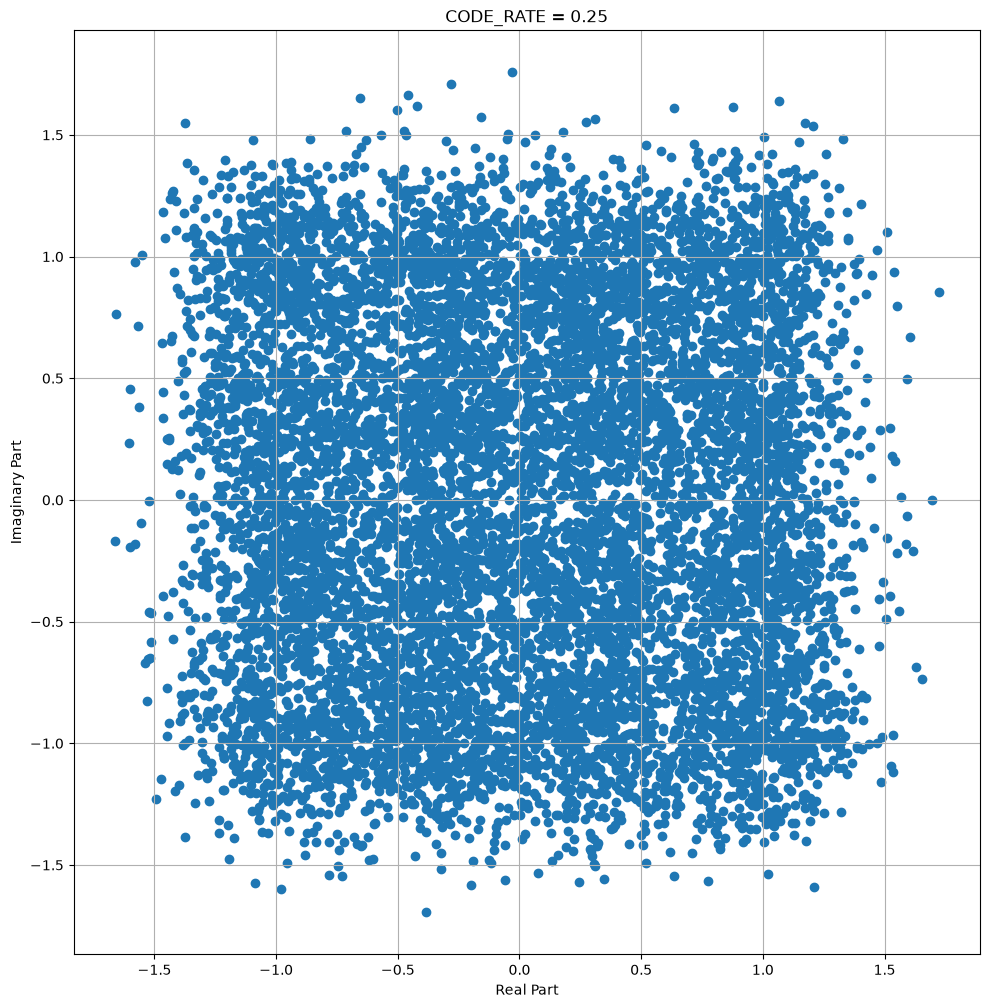

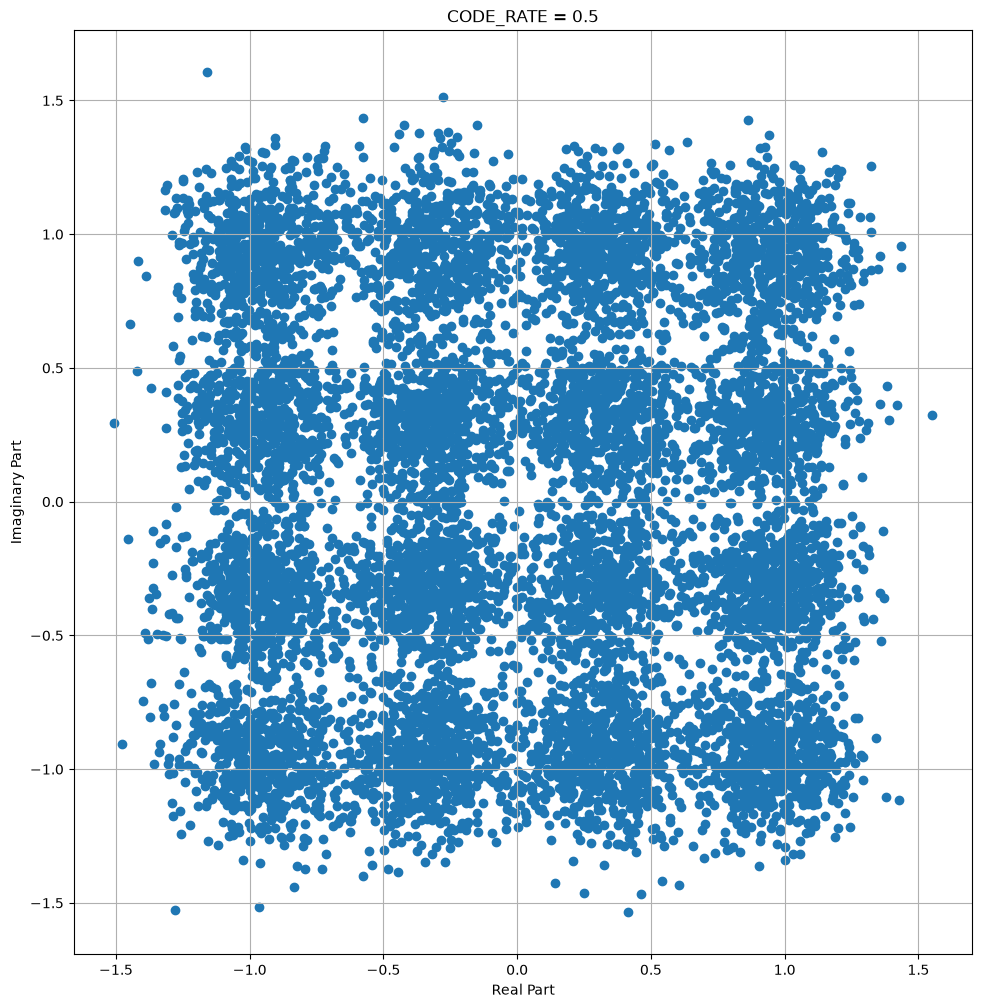

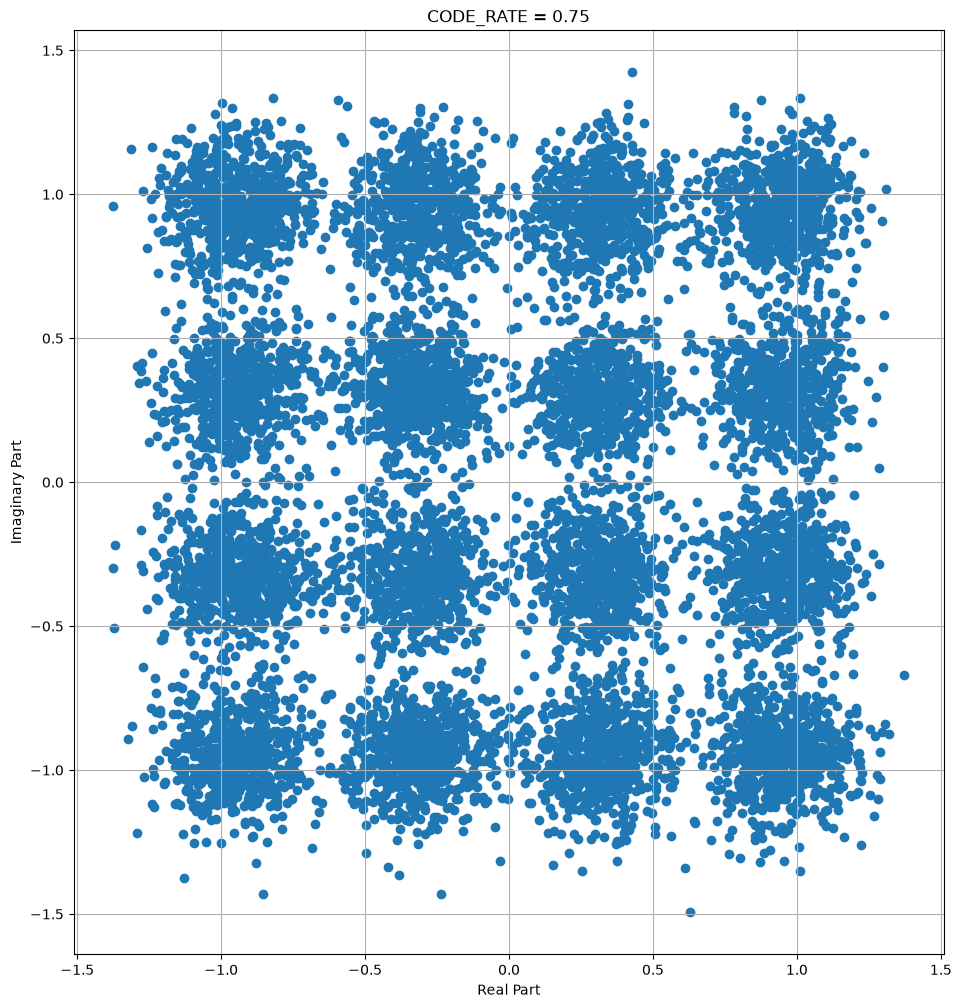

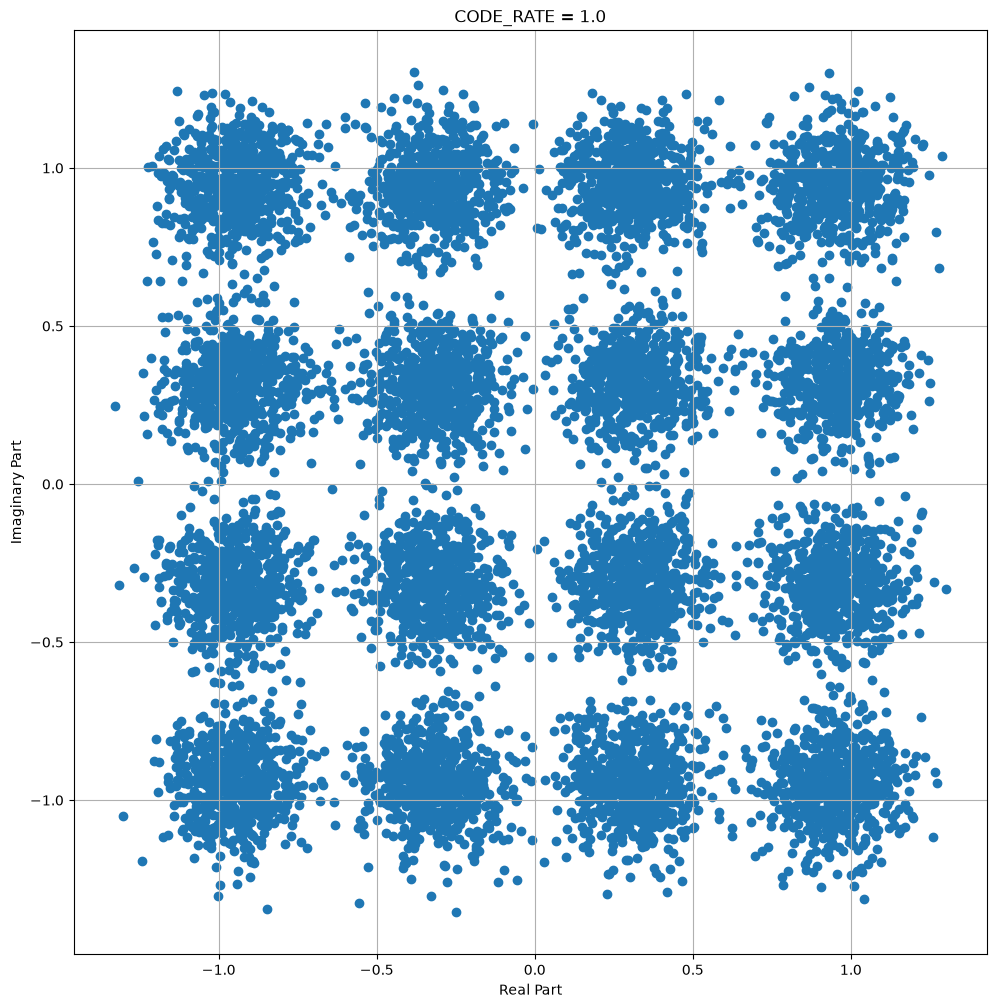

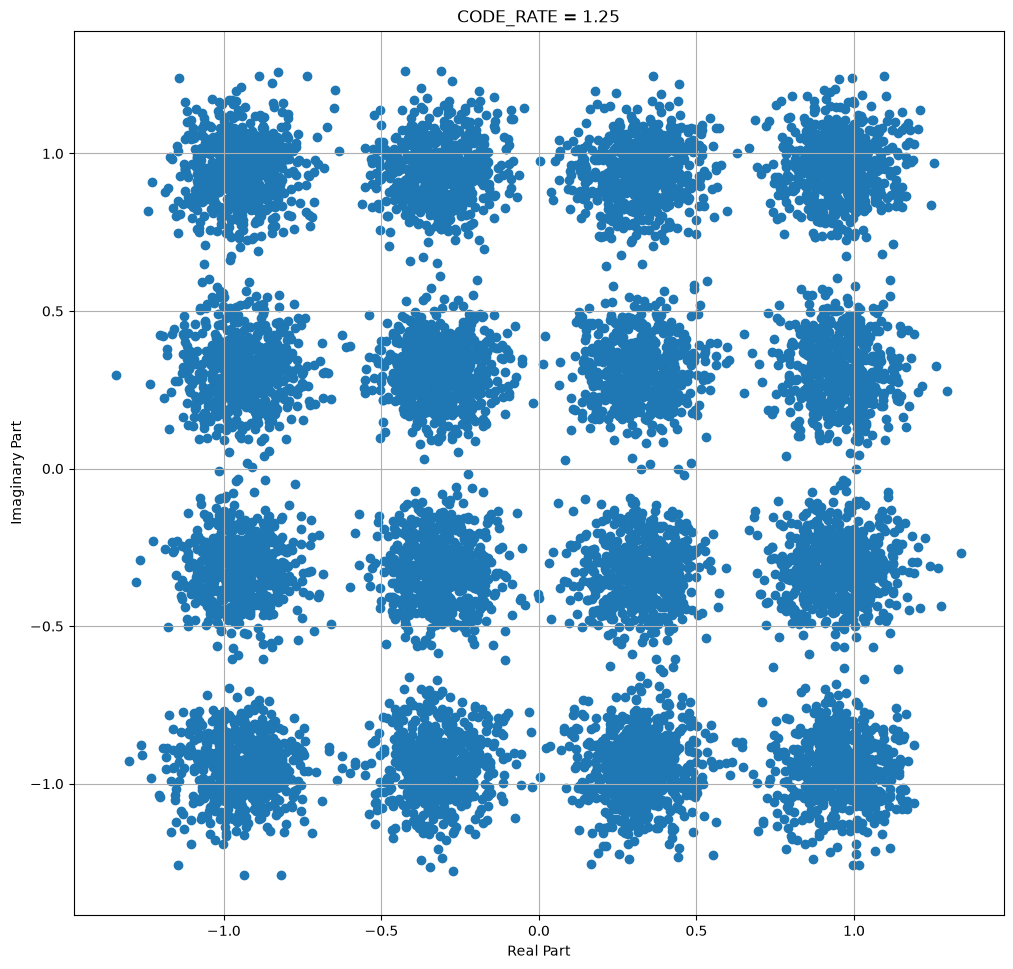

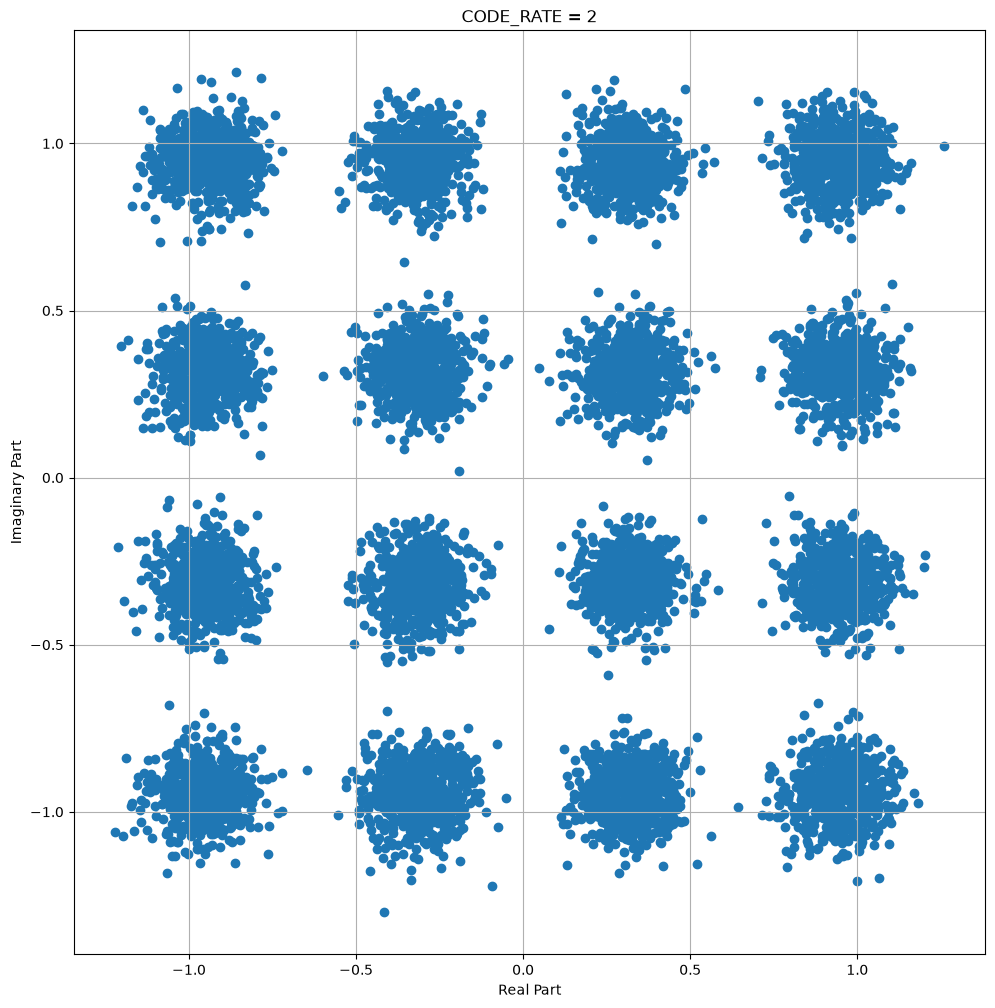

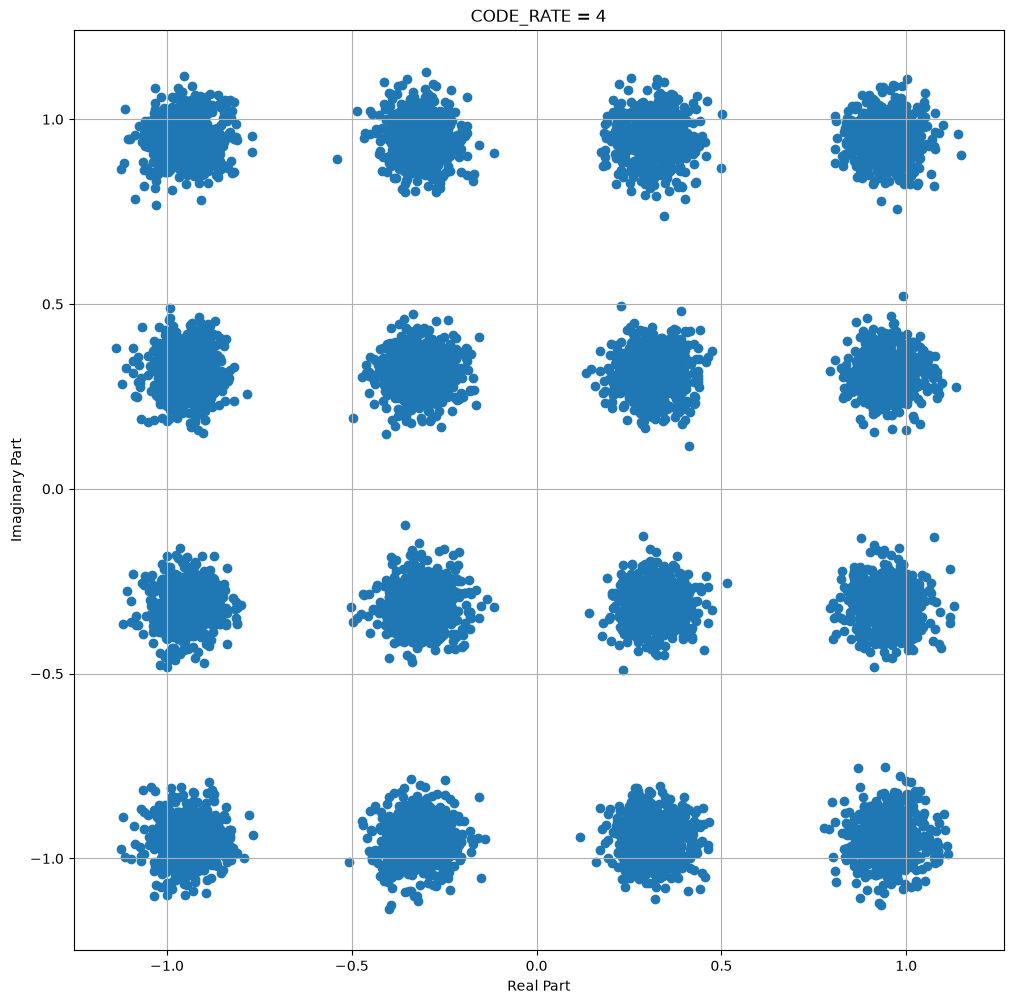

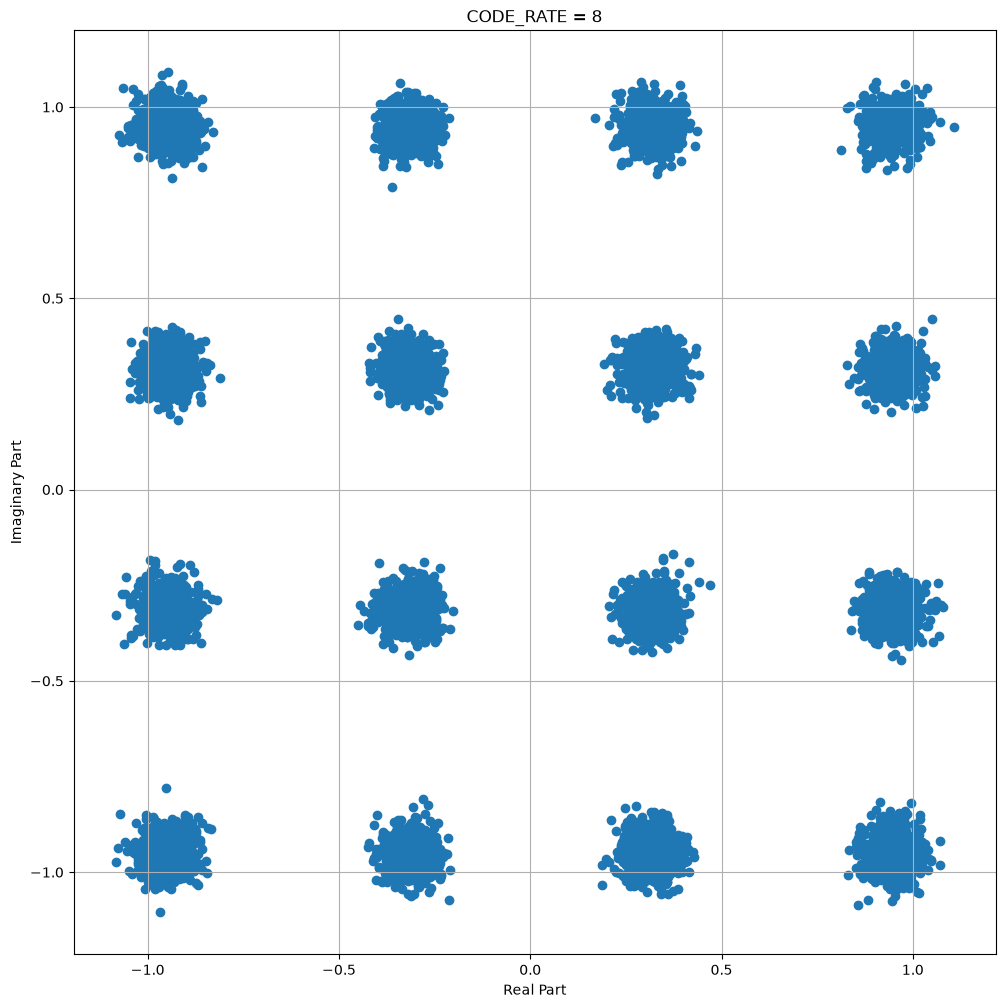

In [55]:
from sionna.phy.mapping import Mapper, Constellation, BinarySource
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no

BITS_PER_SYMBOL = 4
BATCH_SIZE = 10000

source = BinarySource()
bits = source([BATCH_SIZE, BITS_PER_SYMBOL])

constellation = Constellation("qam", BITS_PER_SYMBOL)

mapper = Mapper(constellation=constellation)

x = mapper(bits)

awgn = AWGN()

EBNO_DB = 10
CODE_RATE_VALUES = [0.25, 0.5, 0.75, 1.0, 1.25, 2, 4, 8]

for CODE_RATE in CODE_RATE_VALUES:
    no = ebnodb2no( EBNO_DB, BITS_PER_SYMBOL, CODE_RATE )
    print("NO : " + str(no) + " | " + "CORE_RATE = " + str(CODE_RATE))
    y = awgn(x, no).cpu()

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111)
    plt.scatter(np.real(y), np.imag(y));
    ax.set_aspect("equal", adjustable="box")
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True, which="both", axis="both")
    plt.title("CODE_RATE = " + str(CODE_RATE));


The value of No is calculated as the inverse of:

Eb * r * M divided by No * Es

In this equation:

* Eb : energy per information bit
* r  : is the coderate between ]0, 1]
* M  : is the average number of coded bits per constellation symbol
* No : is the noise power spectral density
* Es : is scaled according to the ratio between the total number of resource elements in a resource grid with non-zero energy and the number of resource elements used for data transmission

Therefore the No is inverse to the r value.

This would mean that the noise variance No is inversely proportional to the r value.

Thus, as the r gets higher and higher in numbers we can see that the variance gets low.

## 6. Manual noise vs. ebnodb2no

Instead of using ebnodb2no, manually compute no from the Eb/N0-to-noise-variance relationship for an uncoded QAM system, and confirm your manual value matches ebnodb2no's output within floating-point tolerance. (This will require you to look up or derive the formula — a good exercise in understanding what ebnodb2no is actually doing under the hood.)

## 7. Symbol error rate

Using Mapper(..., return_indices=True), get the transmitted symbol indices. Pass y through a Demapper (look up its API — you haven't used it yet) to get received bit/symbol estimates, then compute the empirical symbol error rate at EBNO_DB = 10 for 16-QAM. Compare this against a batch size of 1,000 vs. 100,000 — how does the estimate change?

## 8. End-to-end mini pipeline as a function

Wrap the whole "Finally Combining Everything" block into a function simulate(ebno_db, bits_per_symbol, batch_size) that returns y. Call it three times with different parameters and produce a single figure with 3 subplots comparing them. This is good practice for turning notebook cells into reusable code.